# Entrenamiento CNN Clasificador de Roles
Genera `best_cnn_classifier.pth` con Val Acc ~93.6%

Dataset: **volley_detection v5 (Roboflow) en formato YOLOv8**, subido como ZIP.
Tiempo estimado: ~20 minutos en GPU T4


## 0 - Dependencias

In [1]:

print('OK')

OK


In [2]:
import json, random, zipfile
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

SEED = 29348
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

ACTION_CLASSES    = ['attacker','receiver','refree','server','setter']
NUM_ACTION_CLASSES = len(ACTION_CLASSES)
IDX_TO_ACTION     = {i:c for i,c in enumerate(sorted(ACTION_CLASSES))}
print(f'Clases: {IDX_TO_ACTION}')

Dispositivo: cuda
Clases: {0: 'attacker', 1: 'receiver', 2: 'refree', 3: 'server', 4: 'setter'}


## 1 - Subir y descomprimir el ZIP (YOLOv8)

In [3]:

from google.colab import files

uploaded = files.upload()
zip_name = next(iter(uploaded))
print(f'Subido: {zip_name}')

EXTRACT_DIR = Path('/content/volley_dataset')
with zipfile.ZipFile(zip_name) as z:
    z.extractall(EXTRACT_DIR)

# Localizar la carpeta donde esta data.yaml (raiz real del dataset)
yamls = list(EXTRACT_DIR.rglob('data.yaml'))
DATASET_DIR = yamls[0].parent if yamls else EXTRACT_DIR
print(f'Dataset en: {DATASET_DIR}')

Saving volley_detection.v5i.yolov8.zip to volley_detection.v5i.yolov8 (1).zip
Subido: volley_detection.v5i.yolov8 (1).zip
Dataset en: /content/volley_dataset


In [4]:
# Verificar estructura YOLOv8 y leer nombres de clase desde data.yaml
import yaml

with open(DATASET_DIR/'data.yaml') as f:
    data_yaml = yaml.safe_load(f)

YOLO_NAMES = data_yaml['names']            # lista de nombres por indice de clase
if isinstance(YOLO_NAMES, dict):           # por si viene como {0:'...',1:'...'}
    YOLO_NAMES = [YOLO_NAMES[i] for i in range(len(YOLO_NAMES))]
print(f'Clases YOLO (por indice): {YOLO_NAMES}')

for split in ['train','valid','test']:
    img_dir = DATASET_DIR/split/'images'
    lbl_dir = DATASET_DIR/split/'labels'
    ni = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    nl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f'  {split}: {ni} imgs | {nl} labels')

Clases YOLO (por indice): ['attacker', 'receiver', 'refree', 'server', 'setter', 'volleyball']
  train: 960 imgs | 960 labels
  valid: 91 imgs | 91 labels
  test: 45 imgs | 45 labels


## 2 - Extraer crops de jugadores (etiquetas YOLO)

In [5]:
def extract_player_crops(dataset_dir, yolo_names, output_dir='player_crops', min_size=32):
    '''
    Recorta cada anotacion de jugador del dataset en formato YOLOv8.
    Las etiquetas YOLO estan normalizadas (0-1): class x_center y_center w h.
    Excluye la clase volleyball (solo queremos personas).
    Organiza los crops en carpetas por clase para ImageFolder/ActionDataset.
    '''
    output_dir = Path(output_dir)
    stats = defaultdict(int)
    for split in ['train','valid']:
        img_dir = Path(dataset_dir)/split/'images'
        lbl_dir = Path(dataset_dir)/split/'labels'
        if not img_dir.exists() or not lbl_dir.exists(): continue
        for lbl_path in lbl_dir.glob('*.txt'):
            # buscar la imagen correspondiente a la etiqueta
            img_path = None
            for ext in ('.jpg','.jpeg','.png'):
                cand = img_dir/(lbl_path.stem+ext)
                if cand.exists(): img_path = cand; break
            if img_path is None: continue
            img = Image.open(img_path).convert('RGB')
            W, H = img.size
            with open(lbl_path) as f:
                lines = f.read().strip().splitlines()
            for n, line in enumerate(lines):
                parts = line.split()
                if len(parts) < 5: continue
                cid   = int(float(parts[0]))
                cname = yolo_names[cid]
                if cname == 'volleyball': continue  # Solo personas
                xc, yc, w, h = map(float, parts[1:5])
                # de normalizado YOLO a pixeles (esquina sup-izq + ancho/alto)
                bw, bh = w*W, h*H
                x1 = max(0, int(round(xc*W - bw/2)))
                y1 = max(0, int(round(yc*H - bh/2)))
                x2 = min(W, int(round(xc*W + bw/2)))
                y2 = min(H, int(round(yc*H + bh/2)))
                if (x2-x1) < min_size or (y2-y1) < min_size: continue
                crop = img.crop((x1, y1, x2, y2))
                sd = output_dir/split/cname
                sd.mkdir(parents=True, exist_ok=True)
                crop.save(sd/f'{lbl_path.stem}_{n:03d}.jpg')
                stats[f'{split}/{cname}'] += 1
    print('Crops extraidos:')
    for k,v in sorted(stats.items()): print(f'  {k}: {v}')
    return output_dir

CROPS_DIR = extract_player_crops(DATASET_DIR, YOLO_NAMES)
print(f'Crops en: {CROPS_DIR}')

Crops extraidos:
  train/attacker: 3784
  train/receiver: 6034
  train/refree: 1921
  train/server: 125
  train/setter: 1134
  valid/attacker: 179
  valid/receiver: 329
  valid/refree: 149
  valid/server: 11
  valid/setter: 44
Crops en: player_crops


## 3 - Dataset de crops

In [6]:
class ActionDataset(Dataset):
    '''
    Dataset de crops de jugadores para clasificacion de roles.
    Aplica augmentacion en train: flip, color jitter, rotacion.
    '''
    def __init__(self, root_dir, split='train', img_size=224):
        self.root_dir = Path(root_dir)/split
        self.is_train = (split == 'train')
        self.samples  = []
        self.class_to_idx = {c:i for i,c in enumerate(sorted(ACTION_CLASSES))}

        tf_train = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        tf_val = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        self.tf = tf_train if self.is_train else tf_val

        for cname in sorted(ACTION_CLASSES):
            cdir = self.root_dir/cname
            if not cdir.exists(): continue
            idx = self.class_to_idx[cname]
            for p in cdir.glob('*.jpg'):
                self.samples.append((p, idx))
        print(f'ActionDataset "{split}": {len(self.samples)} crops')

    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, label = self.samples[i]
        return self.tf(Image.open(p).convert('RGB')), label

train_ds = ActionDataset(CROPS_DIR, 'train')
val_ds   = ActionDataset(CROPS_DIR, 'valid')
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
print(f'Batches -- train: {len(train_dl)} | val: {len(val_dl)}')

ActionDataset "train": 12998 crops
ActionDataset "valid": 712 crops
Batches -- train: 407 | val: 23


## 4 - Arquitectura CNN propia

In [7]:
class VolleyballCNN(nn.Module):
    '''
    CNN propia para clasificar el rol del jugador.

    Arquitectura:
    - 4 bloques: Conv2d(3x3) + BatchNorm + ReLU + MaxPool2d(2x2)
    - Canales: 3->32->64->128->256
    - Cabeza FC: AdaptiveAvgPool -> Flatten -> Linear(256,128) -> ReLU -> Dropout -> Linear(128,5)

    BatchNorm estabiliza el entrenamiento.
    AdaptiveAvgPool reduce parametros vs Flatten directo.
    Dropout(0.5) regulariza para evitar overfitting.
    Total parametros: ~422,917
    '''
    def __init__(self, num_classes=5, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Bloque 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Bloque 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Bloque 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Cabeza MLP (Fully Connected)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # Global Average Pooling
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

model = VolleyballCNN(num_classes=NUM_ACTION_CLASSES).to(DEVICE)
print(f'Parametros entrenables: {model.count_parameters():,}')
print(f'Clases: {NUM_ACTION_CLASSES} -- {sorted(ACTION_CLASSES)}')

Parametros entrenables: 422,917
Clases: 5 -- ['attacker', 'receiver', 'refree', 'server', 'setter']


## 5 - Entrenamiento

In [8]:
def train_cnn(model, train_dl, val_dl, epochs=25, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc = 0.0

    for epoch in range(epochs):
        # -- Train --
        model.train()
        tl, tc, tt = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tl += loss.item()
            tc += out.argmax(1).eq(labels).sum().item()
            tt += labels.size(0)
        scheduler.step()

        # -- Val --
        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                vl  += criterion(out, labels).item()
                vc  += out.argmax(1).eq(labels).sum().item()
                vt  += labels.size(0)

        tr_loss, vl_loss = tl/len(train_dl), vl/len(val_dl)
        tr_acc,  vl_acc  = tc/max(tt,1),     vc/max(vt,1)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Guardar mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), 'best_cnn_classifier.pth')

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoca [{epoch+1:3d}/{epochs}] '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
                  f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}')

    print(f'Mejor Val Acc: {best_val_acc:.3f}')
    return history

history = train_cnn(model, train_dl, val_dl, epochs=25, lr=1e-3)

Epoca [  1/25] Train Loss: 0.8551 Acc: 0.664 | Val Loss: 0.5814 Acc: 0.822
Epoca [  5/25] Train Loss: 0.6603 Acc: 0.738 | Val Loss: 0.5264 Acc: 0.805
Epoca [ 10/25] Train Loss: 0.5543 Acc: 0.774 | Val Loss: 0.3916 Acc: 0.855
Epoca [ 15/25] Train Loss: 0.4603 Acc: 0.809 | Val Loss: 0.2579 Acc: 0.916
Epoca [ 20/25] Train Loss: 0.3853 Acc: 0.845 | Val Loss: 0.2077 Acc: 0.924
Epoca [ 25/25] Train Loss: 0.3538 Acc: 0.858 | Val Loss: 0.2003 Acc: 0.926
Mejor Val Acc: 0.931


## 6 - Curvas de aprendizaje

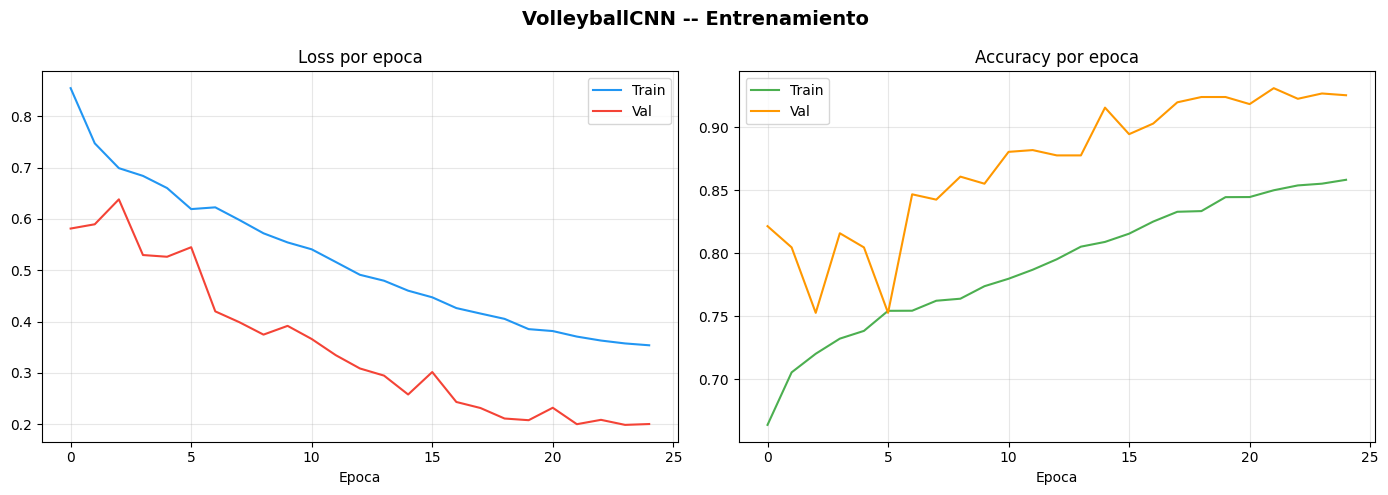

Grafica guardada: cnn_training_history.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', color='#2196F3')
ax1.plot(history['val_loss'],   label='Val',   color='#F44336')
ax1.set_title('Loss por epoca'); ax1.set_xlabel('Epoca')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', color='#4CAF50')
ax2.plot(history['val_acc'],   label='Val',   color='#FF9800')
ax2.set_title('Accuracy por epoca'); ax2.set_xlabel('Epoca')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('VolleyballCNN -- Entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: cnn_training_history.png')

## 7 - Evaluacion en test

ActionDataset "valid": 712 crops
              precision    recall  f1-score   support

    attacker       0.85      0.91      0.88       179
    receiver       0.96      0.97      0.97       329
      refree       1.00      1.00      1.00       149
      server       1.00      0.73      0.84        11
      setter       0.76      0.57      0.65        44

    accuracy                           0.93       712
   macro avg       0.91      0.83      0.87       712
weighted avg       0.93      0.93      0.93       712



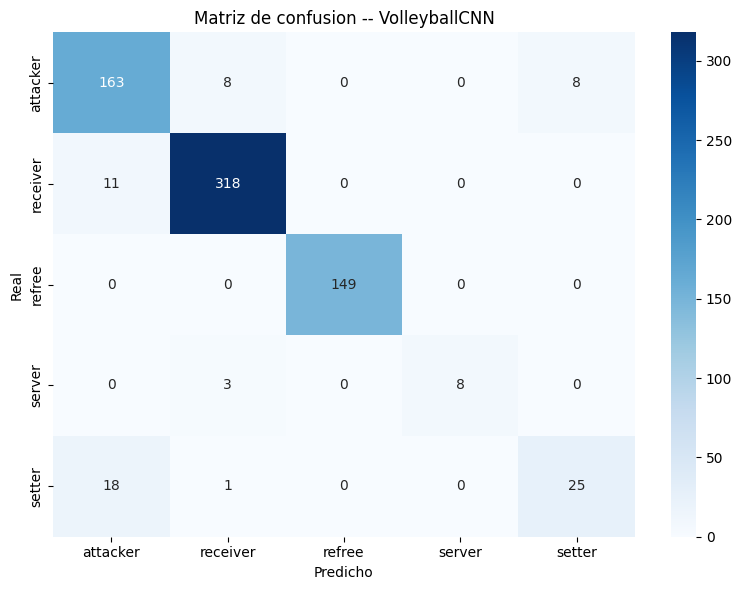

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar mejor modelo
model.load_state_dict(torch.load('best_cnn_classifier.pth', map_location=DEVICE))
model.eval()

# Dataset de test
test_ds = ActionDataset(CROPS_DIR, 'valid')  # Usamos valid como test
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = sorted(ACTION_CLASSES)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Matriz de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusion -- VolleyballCNN')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

## 8 - Descargar pesos

In [11]:
from google.colab import files
files.download('best_cnn_classifier.pth')
print('Descargado: best_cnn_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: best_cnn_classifier.pth
